# Smooth Bradley–Terry demo — Boerstler data

We fit the model $P(\text{choose left}) = \sigma(B_\beta(s_t) \cdot d_t)$ where

- $d_t = \log r_{\text{left},t} - \log r_{\text{right},t}$ — log-ratio of BT ratings  
- $s_t = r_{\text{left},t} + r_{\text{right},t}$ — total quality of the pair  
- $B_\beta(s) = \sum_k \beta_k \phi_k(s)$ — smooth discriminability function  

BT ratings are derived from the corrected logistic-regression fit (alco and crim sign-flipped).  
We compare polynomial bases of degree 0, 1, 2 and check whether $B(s)$ is truly constant.

In [1]:
import importlib
import sys, os
sys.path.insert(0, os.getcwd())  # ensure smooth_bt.py is importable

import smooth_bt
importlib.reload(smooth_bt)       # pick up any edits without restarting kernel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from scipy.special import expit

df = pd.read_csv('boerstler_data_labeled.csv', index_col=0)

L_COLS    = ['lalco', 'ldep', 'llife', 'lcrim']
R_COLS    = ['ralco', 'rdep', 'rlife', 'rcrim']
DIFF_COLS = ['alcodiff', 'depdiff', 'lifediff', 'crimdiff']
SIGN      = np.array([-1., 1., 1., -1.])   # negate alco & crim: higher = better

RAW_MAX = np.array([df[c].abs().max() for c in DIFF_COLS], dtype=float)
print('Loaded:', df.shape)
print('RAW_MAX (diff cols):', np.round(RAW_MAX, 3))


Loaded: (12369, 48)
RAW_MAX (diff cols): [4. 2. 4. 2.]


In [2]:
# ── Person 0 data ────────────────────────────────────────────────────────────
p0   = df[df['person_id'] == 0].sort_index()
T    = len(p0)

L = p0[L_COLS].values.astype(float)   # absolute left-item attributes
R = p0[R_COLS].values.astype(float)   # absolute right-item attributes
c = p0[DIFF_COLS].values / RAW_MAX    # normalised signed differences (T, 4)

# choice: 0 = left, 1 = right  →  y=1 means left was chosen
y = (p0['chosen'].values == 0).astype(float)

print(f'Person 0: {T} trials, {y.mean():.3f} chose left')
print(f'L range: min={L.min():.2f}  max={L.max():.2f}')
print(f'R range: min={R.min():.2f}  max={R.max():.2f}')


Person 0: 600 trials, 0.505 chose left
L range: min=-1.00  max=4.00
R range: min=-1.00  max=4.00


In [3]:
# ── Fit standard BT (logistic regression on sign-corrected diffs) ────────────
c_bt = c * SIGN    # sign-corrected differences; shape (T, 4)

bt = LogisticRegression(fit_intercept=False, C=1e6, max_iter=1000)
bt.fit(c_bt, y)
beta_bt = bt.coef_[0]   # shape (4,); all positive after sign correction

print('Standard BT fit:')
print(f'  beta (raw):        {np.round(beta_bt, 3)}')
print(f'  accuracy:          {bt.score(c_bt, y):.3f}')
print(f'  log-likelihood:    {-log_loss(y, bt.predict_proba(c_bt)[:,1], normalize=False):.3f}')


Standard BT fit:
  beta (raw):        [1.791 6.968 4.801 4.442]
  accuracy:          0.912
  log-likelihood:    -121.891


In [4]:
# ── Compute per-trial BT ratings from absolute attribute values ───────────────
#
# BT score for a policy bundle x:  score(x) = beta_bt @ x_corrected
# where x_corrected applies SIGN to flip alco and crim, then normalises
# by the attribute range so scores live on the same scale as the diff-based fit.
#
# Normalise each absolute attribute by RAW_MAX (max absolute diff),
# which is the natural scale factor used in the BT fit.

L_norm = L * SIGN / RAW_MAX   # sign-corrected, normalised left attrs  (T, 4)
R_norm = R * SIGN / RAW_MAX   # sign-corrected, normalised right attrs (T, 4)

score_L = L_norm @ beta_bt    # BT log-score for each left item  (T,)
score_R = R_norm @ beta_bt    # BT log-score for each right item (T,)

r_left  = np.exp(score_L)     # positive BT rating for left item
r_right = np.exp(score_R)     # positive BT rating for right item

d_t = score_L - score_R       # log-ratio = beta_bt @ c_bt  (verify below)
s_t = r_left + r_right        # total quality of the pair

# Sanity check: d_t should equal beta_bt @ c_bt (up to floating point)
d_check = c_bt @ beta_bt
print(f'Max |d_t - beta_bt @ c_bt|: {np.abs(d_t - d_check).max():.2e}  (should be ~0)')
print(f'd_t  range: [{d_t.min():.3f}, {d_t.max():.3f}]')
print(f's_t  range: [{s_t.min():.3f}, {s_t.max():.3f}]')
print(f'r_left  range: [{r_left.min():.3f}, {r_left.max():.3f}]')
print(f'r_right range: [{r_right.min():.3f}, {r_right.max():.3f}]')

# Pack into arrays for smooth_bt:
# treat each trial's left and right as unique 'items'
r_all   = np.concatenate([r_left, r_right])   # length 2T
ri_idx  = np.arange(T)                        # left-item indices
rj_idx  = np.arange(T, 2 * T)                 # right-item indices


Max |d_t - beta_bt @ c_bt|: 3.55e-15  (should be ~0)
d_t  range: [-18.002, 18.002]
s_t  range: [0.055, 39486.414]
r_left  range: [0.001, 38898.321]
r_right range: [0.001, 38898.321]


In [5]:
# ── Fit smooth BT for polynomial degrees 0, 1, 2 ────────────────────────────
#
# Degree 0:  B(s) = beta_0             (constant, equivalent to standard BT)
# Degree 1:  B(s) = beta_0 + beta_1*s  (linear:  discriminability varies with scale)
# Degree 2:  B(s) = beta_0 + beta_1*s + beta_2*s^2  (quadratic)

fits = {}
for deg in [0, 1, 2]:
    phi_list, dphi_list = smooth_bt.make_poly_basis(deg)
    out = smooth_bt.fit(ri_idx, rj_idx, y, r_all, phi_list, dphi_list=dphi_list)
    fits[deg] = out
    k     = deg + 1
    aic   = 2 * k - 2 * out['log_lik']
    se_str = '  '.join(
        f'{b:.3f} ({e:.3f})' if e is not None else f'{b:.3f}'
        for b, e in zip(out['beta_hat'],
                        out['se'] if out['se'] is not None else [None]*k)
    )
    print(f'deg={deg}  K={k}  log-lik={out["log_lik"]:>9.3f}  AIC={aic:>9.3f}  '
          f'beta (SE): {se_str}')


deg=0  K=1  log-lik= -121.891  AIC=  245.782  beta (SE): 1.000 (0.097)
deg=1  K=2  log-lik= -120.989  AIC=  245.977  beta (SE): 0.949 (0.102)  0.000 (0.000)
deg=2  K=3  log-lik= -234.097  AIC=  474.193  beta (SE): 0.000 (0.038)  0.001 (0.000)  -0.000 (0.000)


/Users/michellesi/Desktop/harvard/topmodel/new_model/smooth_bt.py:365: RuntimeWarning: Optimiser did not converge: ABNORMAL_TERMINATION_IN_LNSRCH
  warnings.warn(


In [6]:
# ── Likelihood-ratio tests ───────────────────────────────────────────────────
from scipy.stats import chi2

print('Likelihood-ratio tests:')
for (d0, d1) in [(0, 1), (1, 2)]:
    ll0 = fits[d0]['log_lik']
    ll1 = fits[d1]['log_lik']
    lrt = 2 * (ll1 - ll0)
    df_diff = (d1 + 1) - (d0 + 1)
    p = 1 - chi2.cdf(lrt, df=df_diff)
    print(f'  deg {d0} vs deg {d1}:  LRT={lrt:.3f}  df={df_diff}  p={p:.4f}')


Likelihood-ratio tests:
  deg 0 vs deg 1:  LRT=1.805  df=1  p=0.1791
  deg 1 vs deg 2:  LRT=-226.216  df=1  p=1.0000


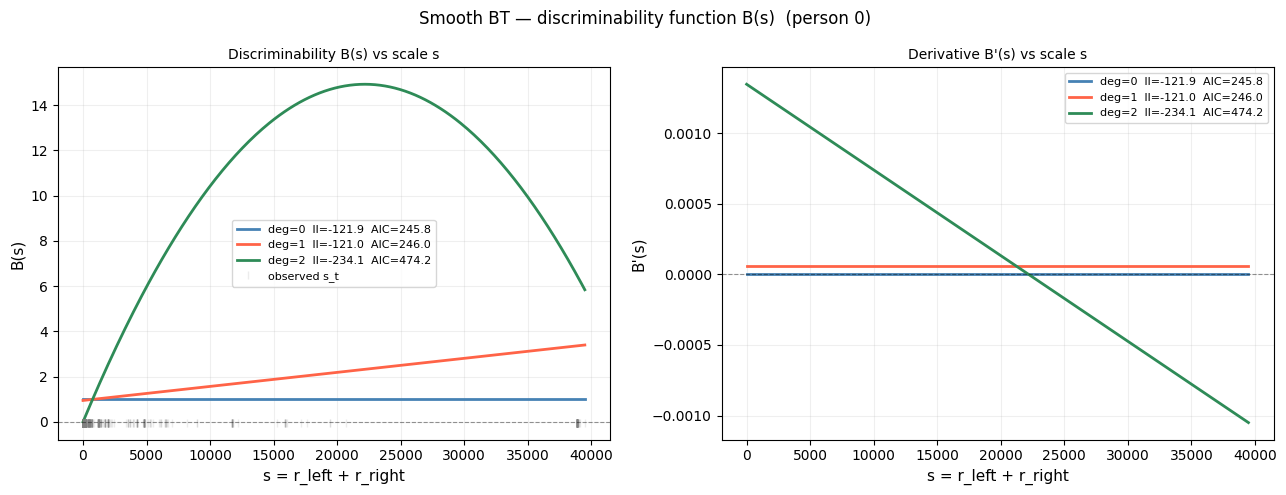

Saved smooth_bt_B.png


In [7]:
# ── Plot B(s) for all three models ───────────────────────────────────────────
s_range = np.linspace(s_t.min(), s_t.max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Smooth BT — discriminability function B(s)  (person 0)", fontsize=12)

colors = ['steelblue', 'tomato', 'seagreen']
for deg, col in zip([0, 1, 2], colors):
    out = fits[deg]
    phi_list, dphi_list = smooth_bt.make_poly_basis(deg)
    B_vals  = smooth_bt.B(s_range, out['beta_hat'], phi_list)
    dB_vals = smooth_bt.B(s_range, out['beta_hat'], dphi_list)
    k   = deg + 1
    aic = 2 * k - 2 * out['log_lik']
    lbl = f'deg={deg}  ll={out["log_lik"]:.1f}  AIC={aic:.1f}'
    axes[0].plot(s_range, B_vals,  lw=2, color=col, label=lbl)
    axes[1].plot(s_range, dB_vals, lw=2, color=col, label=lbl)

# Rug: observed s_t values
axes[0].plot(s_t, np.zeros_like(s_t) - 0.03, '|', color='gray',
             alpha=0.15, ms=6, label='observed s_t')

for ax, ylabel, title in [
    (axes[0], 'B(s)',  'Discriminability B(s) vs scale s'),
    (axes[1], "B'(s)", "Derivative B'(s) vs scale s"),
]:
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.set_xlabel('s = r_left + r_right', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('smooth_bt_B.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved smooth_bt_B.png')


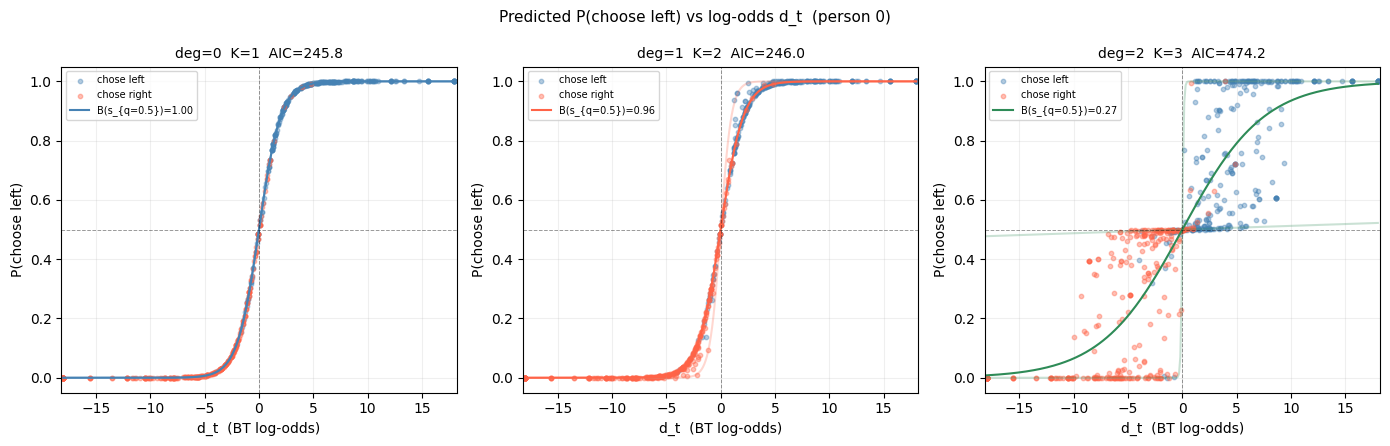

Saved smooth_bt_probs.png


In [8]:
# ── Predicted prob vs d_t, coloured by choice ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Predicted P(choose left) vs log-odds d_t  (person 0)', fontsize=11)

for ax, deg, col in zip(axes, [0, 1, 2], colors):
    out = fits[deg]
    p   = out['probs']
    order = np.argsort(d_t)
    ax.scatter(d_t[y==1], p[y==1], c='steelblue', s=10, alpha=0.4, label='chose left')
    ax.scatter(d_t[y==0], p[y==0], c='tomato',    s=10, alpha=0.4, label='chose right')
    xs = np.linspace(d_t.min(), d_t.max(), 300)
    # For each degree, show the median-s sigmoid and the spread across s quantiles
    phi_list, _ = smooth_bt.make_poly_basis(deg)
    for q, alpha in [(0.1, 0.25), (0.5, 1.0), (0.9, 0.25)]:
        sq   = np.quantile(s_t, q)
        Bval = smooth_bt.B(sq, out['beta_hat'], phi_list)
        ys   = expit(Bval * xs)
        lbl  = f'B(s_{{q={q}}})={Bval:.2f}' if alpha == 1.0 else None
        ax.plot(xs, ys, color=col, lw=1.5, alpha=alpha, label=lbl)
    ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.4)
    ax.axhline(0.5, color='black', lw=0.7, ls='--', alpha=0.4)
    ax.set_xlim(d_t.min()-0.2, d_t.max()+0.2)
    ax.set_ylim(-0.05, 1.05)
    k   = deg + 1
    aic = 2*k - 2*out['log_lik']
    ax.set_title(f'deg={deg}  K={k}  AIC={aic:.1f}', fontsize=10)
    ax.set_xlabel('d_t  (BT log-odds)', fontsize=10)
    ax.set_ylabel('P(choose left)', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('smooth_bt_probs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved smooth_bt_probs.png')
